In [1]:
root_backup = "../../../dump"
root = "VA_results"
n = 0
q = 2700
k = 0
m = 1500
window_size = 50
fig_size = (10,8)

In [2]:
grid_styles = [
    {'linestyle': '-', 'linewidth': 0.75, 'alpha': 0.6, 'color': 'gray'},
    {'linestyle': '--', 'linewidth': 1.2, 'alpha': 0.7, 'color': 'tab:red'},
    {'linestyle': ':', 'linewidth': 1.5, 'alpha': 0.8, 'color': 'tab:green', 'axis': 'x'},
    {'linestyle': '-.', 'linewidth': 1, 'alpha': 0.6, 'color': 'tab:purple', 'minor': True}
]

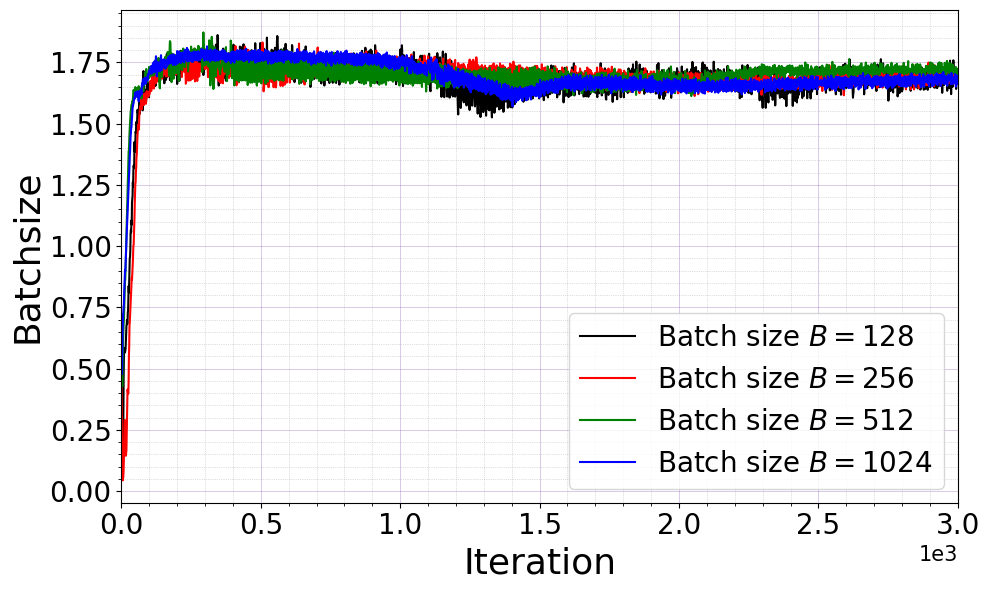

In [3]:
from matplotlib.ticker import ScalarFormatter
import matplotlib.pyplot as plt
import json

# Load the results for each model
def load_results(paths, type="revenue"):
    lenpath = len(paths)
    results = []
    for i in range(lenpath):
        with open(paths[i], "r") as f:
            results.append(json.load(f)[type][n:])
    return results

path_batch_size = [f"../{root_backup}/runs_RegretFormer_batch_size128/setting_default_config_128/seed_0/model_result_3000_5x3_0.001",
                   f"../{root_backup}/runs_RegretFormer_batch_size256/setting_default_config_2/seed_0/model_result_3000_5x3_0.001",
                   f"../{root_backup}/runs_RegretFormer_batch_size512/setting_default_config_2_copy/seed_0/model_result_3000_5x3_0.001",
                   f"../{root_backup}/runs_RegretFormer_batch_size1034/setting_default_config_2_copy_2/seed_1/model_result_3000_5x3_0.001"]

def plot_columns_from_paths(paths, columns, colors, labels, figsize=(10, 6), pos = "lower right", 
                            type="revenue", xname="Iteration", yname="Batchsize",grid_styles= grid_styles[3]):

    # Load data from paths
    data = [load_results([path], type=type )[0] for path in paths]

    plt.figure(figsize=figsize)

    for dataset, color, dataset_label in zip(data, colors, labels):
        plt.plot(range(len(dataset)), dataset, color=color, label=dataset_label)

        # Configure plot aesthetics
        plt.xlabel(xname, fontsize=26)
        plt.ylabel(yname, fontsize=26)
        # plt.grid(alpha=1, linestyle='-')
        if 'minor' in grid_styles:
            plt.minorticks_on()
            plt.grid(True, which='major', linestyle='-', linewidth=0.5, color='tab:purple', alpha=0.5)
            plt.grid(True, which='minor', linestyle=':', linewidth=0.5, color='gray', alpha=0.5)           

        else:
            plt.grid(**grid_styles)
        plt.legend(fontsize=20, loc=pos)
        plt.xticks(fontsize=20)
        plt.yticks(fontsize=20)
        plt.xlim(left=0, right=len(dataset))


    # Configure scientific notation on the x-axis
    ax = plt.gca()
    ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
    ax.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
    ax.xaxis.get_offset_text().set_fontsize(15)

    # Adjust layout and display
    plt.tight_layout()
    plt.show()


# Define variables
columns_in_progress = [
    "Batch size $B=128$",
    "Batch size $B=256$",
    "Batch size $B=512$",
    "Batch size $B=1024$",
]
colors = ["black", "red", "green", "blue"]
labels = columns_in_progress

# Call the function with path_batch_size
plot_columns_from_paths(path_batch_size, columns_in_progress, colors, labels, grid_styles=grid_styles[3])

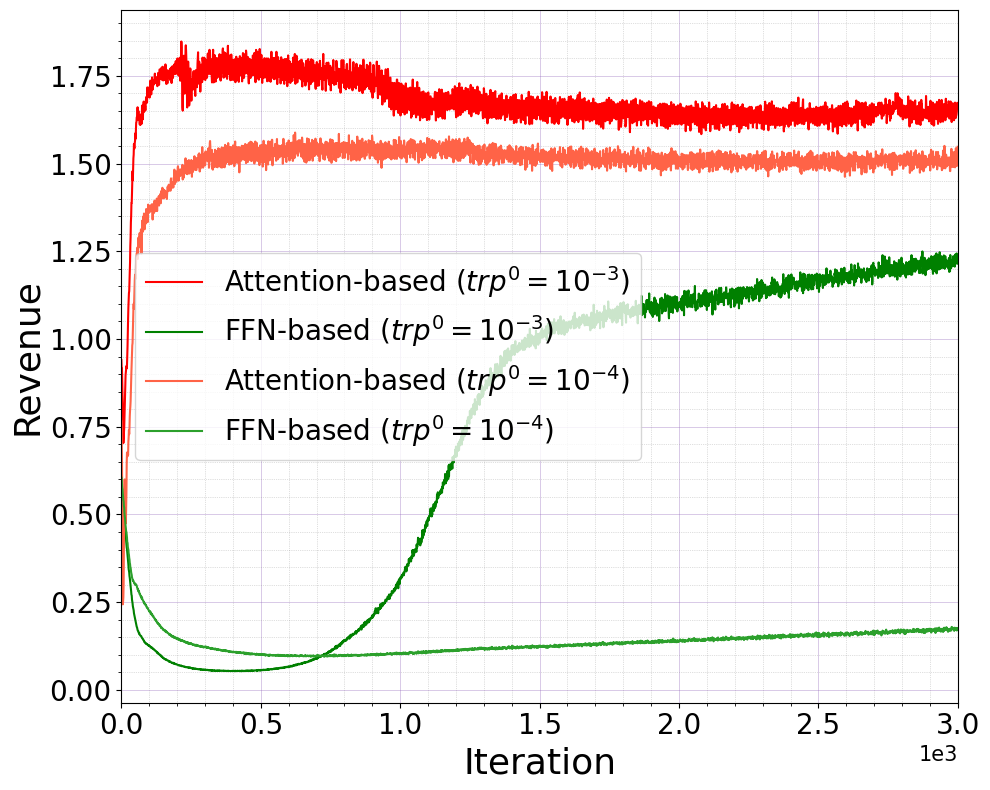

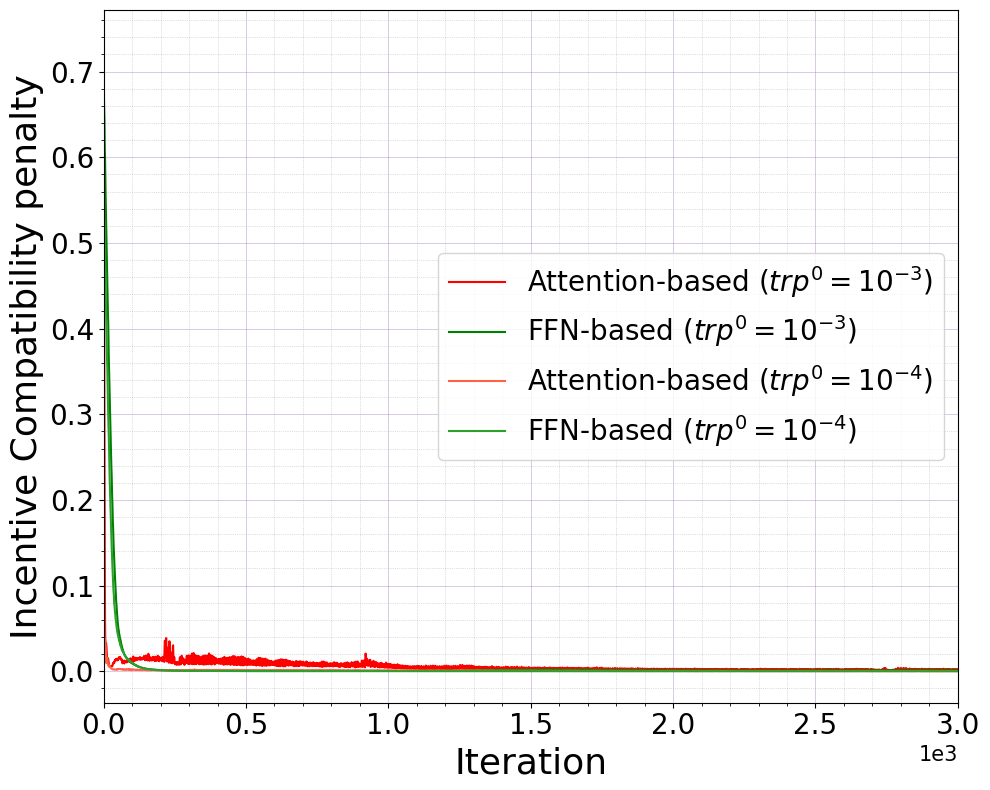

In [4]:
path_trp = ["../runs_RegretFormer/setting_default_config/seed_0/model_result_3000_5x3_0.001",
             "../runs_RegretNet/setting_default_config/seed_0/model_result_3000_5x3_0.001",
             "../runs_RegretFormer/setting_default_config_trp/seed_0/model_result_3000_5x3_0.0001", 
             "../runs_RegretNet/setting_default_config_trp/seed_0/model_result_3000_5x3_0.0001"]

columns_in_progress = [
    "Attention-based ($trp^0= 10^{-3}$)",
    "FFN-based ($trp^0= 10^{-3}$)",
    "Attention-based ($trp^0= 10^{-4}$)",
    "FFN-based ($trp^0= 10^{-4}$)"
]

colors = ["red", "green", "tomato", "tab:green"]
labels = columns_in_progress


plot_columns_from_paths(path_trp, columns_in_progress, colors, labels, figsize=(10,8), type="revenue", xname="Iteration", yname="Revenue", pos="center left")
plot_columns_from_paths(path_trp, columns_in_progress, colors, labels, figsize=(10,8), type="regret", pos="center right", xname="Iteration", yname="Incentive Compatibility penalty")

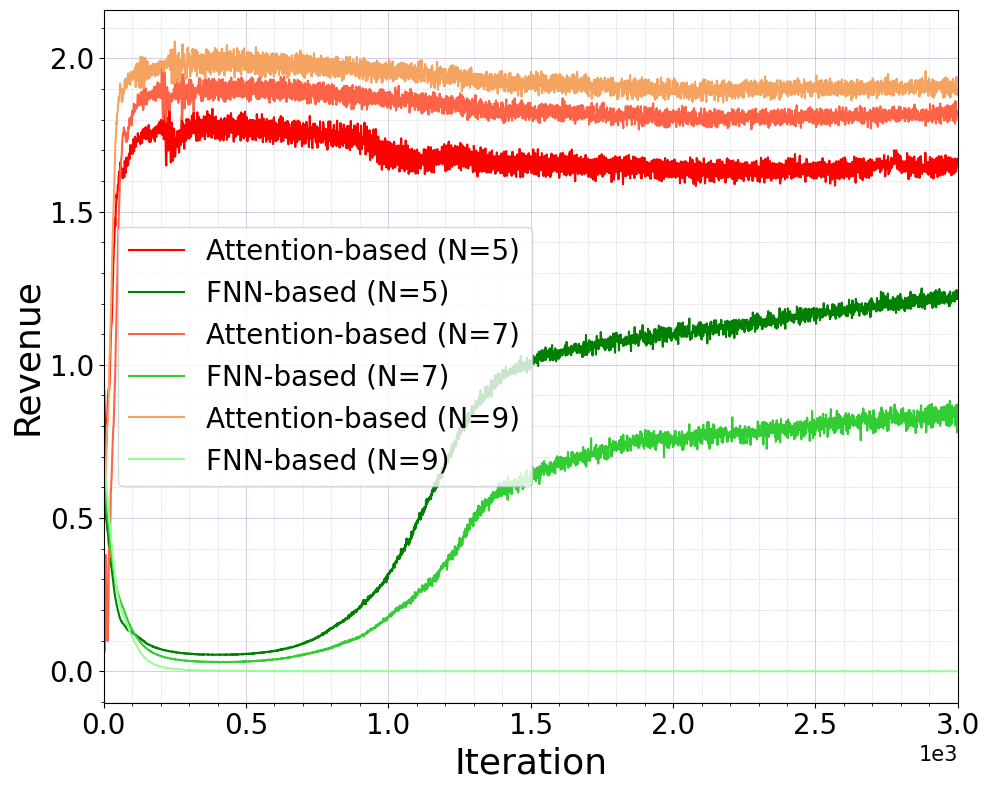

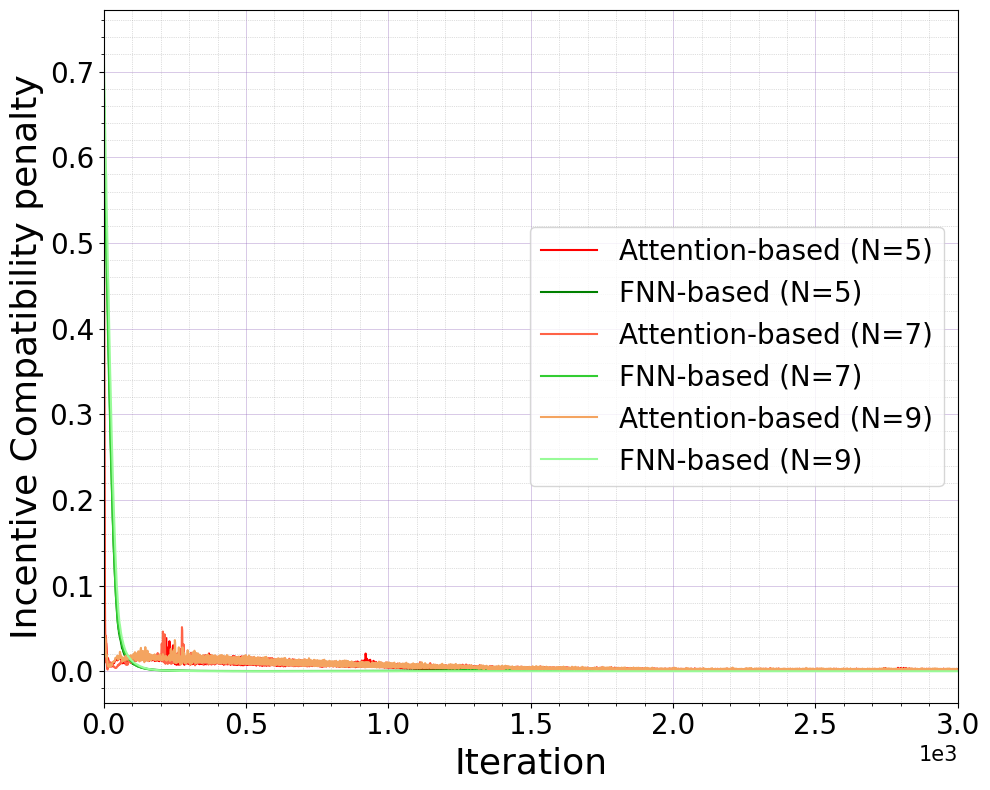

In [5]:
path5x3 = ["../runs_RegretFormer/setting_default_config/seed_0/model_result_3000_5x3_0.001",
           "../runs_RegretNet/setting_default_config/seed_0/model_result_3000_5x3_0.001",
           "../runs_RegretFormer/setting_default_config_2/seed_0/model_result_3000_7x3_0.001",
           "../runs_RegretNet/setting_default_config_2/seed_1/model_result_3000_7x3_0.001",
           "../runs_RegretFormer/setting_default_config_3/seed_1/model_result_3000_9x3_0.001",
           "../runs_RegretNet/setting_default_config_3/seed_1/model_result_3000_9x3_0.001"]

columns_in_progress = [
    "Attention-based (N=5)",
    "FNN-based (N=5)",
    "Attention-based (N=7)",
    "FNN-based (N=7)",
    "Attention-based (N=9)",
    "FNN-based (N=9)"
]

colors = ["red", "green", "tomato", "limegreen", "sandybrown", "palegreen"]
labels = columns_in_progress

plot_columns_from_paths(path5x3, columns_in_progress, colors, labels, figsize=(10,8), type="revenue", xname="Iteration", yname="Revenue", pos="center left")
plot_columns_from_paths(path5x3, columns_in_progress, colors, labels, figsize=(10,8), type="regret", pos="center right", xname="Iteration", yname="Incentive Compatibility penalty")

/tmp/ipykernel_2522269/4000882929.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


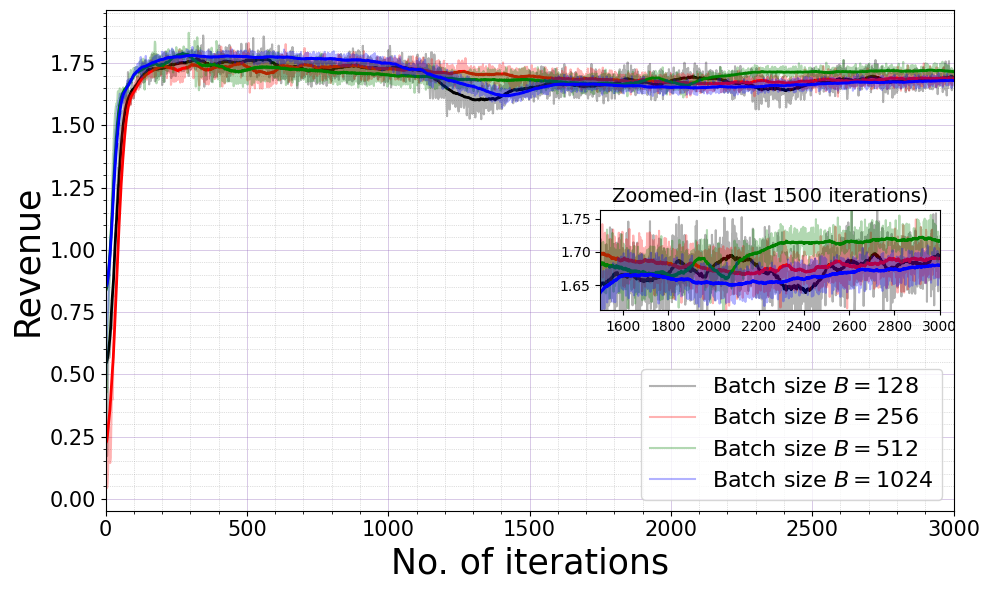

In [6]:
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np

def ploting_iteration(
    list_results,
    window_size=50,
    fig_size=(12, 8),
    save_name="batch_size_comparison.png",
    colors=['black', 'red', 'green', 'blue'],
    m=1500,  # Starting iteration for zoomed-in section
    n=0,     # Starting iteration for overall plot
    save=False,
    labels=['Batch size $B=128$', 'Batch size $B=256$', 'Batch size $B=512$', 'Batch size $B=1024$'],
    xlim=None,
    grid_styles= grid_styles[3]
):
    # Smooth data for better visualization
    smoothes = [uniform_filter1d(i, size=window_size) for i in list_results]
    x_values = np.arange(n, 3000)

    # fig, (ax_main, ax_zoom_out) = plt.subplots(1, 1, figsize=fig_size, gridspec_kw={'height_ratios': [3, 1]})
    fig, ax_main = plt.subplots(1, 1, figsize=fig_size)
    ax_main.set_xlabel("No. of iterations", fontsize=25)
    ax_main.set_ylabel("Revenue", fontsize=25)
    ax_main.tick_params(axis='both', labelsize=15)
    # ax_main.grid(True, linestyle='--', alpha=0.7)
    if 'minor' in grid_styles:
        ax_main.minorticks_on()
        ax_main.grid(True, which='major', linestyle='-', linewidth=0.5, color='tab:purple', alpha=0.5)
        ax_main.grid(True, which='minor', linestyle=':', linewidth=0.5, color='gray', alpha=0.5)
    else:
        ax_main.grid(**grid_styles)
    
    ax_main.set_xlim(0, 3000)
    # Plot both raw and smoothed data on main axes
    for i in range(len(list_results)):
        ax_main.plot(x_values, list_results[i], alpha=0.3, color=colors[i], label=labels[i])
        ax_main.plot(x_values, smoothes[i], color=colors[i], linewidth=2)

    # # Zoomed-in plot
    # ax_inset = inset_axes(ax_main, width="40%", height="20%", loc='center right', borderpad=1)
    # x_zoom = np.arange(m, 3000)
    # for i in range(len(list_results)):
    #     ax_inset.plot(x_zoom, list_results[i][m:], alpha=0.3, color=colors[i])
    #     ax_inset.plot(x_zoom, smoothes[i][m:], color=colors[i], linewidth=2)

    # ax_inset.set_xlim(m, 3000)
    # ax_inset.set_ylim(min(min(list_results[1][m:]), min(smoothes[1][m:])), 
    #                   max(max(list_results[0][m:]), max(smoothes[0][m:])))
    # ax_inset.set_title(f"Zoomed-in (last {3000-m} iterations)", fontsize=12)

    # Zoomed-in plot
    ax_inset = inset_axes(ax_main, width="40%", height="20%", loc='center right', borderpad=1)
    x_zoom = np.arange(m, 3000)
    for i in range(len(list_results)):
        ax_inset.plot(x_zoom, list_results[i][m:], alpha=0.3, color=colors[i])
        ax_inset.plot(x_zoom, smoothes[i][m:], color=colors[i], linewidth=2)

    ax_inset.set_xlim(m, 3000)
    ax_inset.set_ylim(min(min(list_results[1][m:]), min(smoothes[1][m:])), 
                    max(max(list_results[0][m:]), max(smoothes[0][m:])))
    ax_inset.set_title(f"Zoomed-in (last {3000-m} iterations)", fontsize=14)

    # Giảm kích thước chữ tick label cho inset plot
    ax_inset.tick_params(axis='both', labelsize=10)  # Thêm dòng này để giảm kích thước trục x, y


    # Legends and save
    ax_main.legend(loc='lower right', fontsize=16, frameon=True)
    if save:
        plt.savefig(save_name, bbox_inches='tight')
    plt.tight_layout()
    plt.show()

# Example call with your provided data
ploting_iteration(
    list_results=[load_results([path])[0] for path in path_batch_size],
    window_size=50,
    fig_size=(10, 6),
    save_name="batch_size_comparison_zoomed_out.png",
    colors=['black', 'red', 'green', 'blue'],
    m=1500,
    n=0,
    labels=['Batch size $B=128$', 'Batch size $B=256$', 'Batch size $B=512$', 'Batch size $B=1024$']
)


In [7]:
path_103_5x3 = [  f"../{root_backup}/runs_RegretFormer_bidders_103/setting_default_config_2/seed_0/model_result_3000_5x3_0.001",
                     f"../{root}/runs_RegretNet_bidders_103/setting_default_config_2/seed_0/model_result_3000_5x3_0.001",
                f"../{root_backup}/runs_EquivariantNet_bidders_103/setting_default_config_2/seed_0/model_result_3000_5x3_0.001"]
path_103_7x3 = [
                  f"../{root_backup}/runs_RegretFormer_bidders_103/setting_default_config_2_copy/seed_1/model_result_3000_7x3_0.001",
                     f"../{root}/runs_RegretNet_bidders_103/setting_default_config_2_copy/seed_0/model_result_3000_7x3_0.001",
                f"../{root_backup}/runs_EquivariantNet_bidders_103/setting_default_config_2_copy/seed_0/model_result_3000_7x3_0.001"]

path_103_9x3 = [  f"../{root_backup}/runs_RegretFormer_bidders_103/setting_default_config_2_copy_2/seed_1/model_result_3000_9x3_0.001",
                     f"../{root}/runs_RegretNet_bidders_103/setting_default_config_2_copy_2/seed_1/model_result_3000_9x3_0.001",
                f"../{root_backup}/runs_EquivariantNet_bidders_103/setting_default_config_2_copy_2/seed_1/model_result_3000_9x3_0.001"]


colors = {
     'TNN-based approach': ['red', 'tomato', 'sandybrown'],
     'FFN-enabled approach': ['green', 'limegreen', 'palegreen'],
     'Equivariant-based approach': ['blue', 'cornflowerblue', 'steelblue'],
     # 'VCG approach': ['black', 'dimgrey', 'dimgray']
}

result_VCG5x3 = 0.8884
results_VCG5x3 = [result_VCG5x3     for _ in range(3000)]
result_VCG7x3 = 1.1832
results_VCG7x3 = [result_VCG7x3     for _ in range(3000)]
result_VCG9x3 = 1.3334
results_VCG9x3 = [result_VCG9x3     for _ in range((3000))]
figsize = (10, 6)

results5x3 = load_results(path_103_5x3)
results7x3 = load_results(path_103_7x3)
results9x3 = load_results(path_103_9x3)
results_vcg = [results_VCG5x3, results_VCG7x3, results_VCG9x3]

results5x3[2] = [i - 0.04 for i in results5x3[2]]
results7x3[2] = [i - 0.06 for i in results7x3[2]]
results9x3[2] = [i - 0.04 for i in results9x3[2]]

results5x3.append(results_vcg[0])


# ploting_iteration(
#     list_results=results5x3,
#     window_size=window_size,
#     fig_size=figsize,
#     save_name="bidders_comparison_103.png",
#     colors=['red', 'green', 'blue', 'black'],
#     m=m,
#     n=n,
#     labels=['TNN-based approach', 'FFN-enabled approach', 'Equivariant-based approach', 'VCG approach']
# )

FileNotFoundError: [Errno 2] No such file or directory: '../VA_results/runs_RegretNet_bidders_103/setting_default_config_2/seed_0/model_result_3000_5x3_0.001'

In [142]:
import matplotlib.pyplot as plt

# Set font and plot style configurations
plt.rcParams.update({
    'font.size': 35,
    'axes.titlesize': 35,
    'axes.labelsize': 35,
    'xtick.labelsize': 35,
    'ytick.labelsize': 35,
    'legend.fontsize': 35,
})

def plot_comparison_grid(x_values, y_values_list, labels, colors, x_label, y_label, title=None, 
                         save=False, file_name="comparison_plot.png", figsize=(22, 18), 
                         markers=None, line_styles=None, xlim=None, ylim=None, loc = "best"):

    if markers is None:
        markers = ['o', 's', 'v', 'P']
    if line_styles is None:
        line_styles = ['-']

    # Determine grid size based on number of y_values_list entries
    num_subplots = len(y_values_list)
    nrows = (num_subplots + 1) // 2
    ncols = 2 if num_subplots > 1 else 1

    # Create subplots
    fig, axs = plt.subplots(nrows, ncols, figsize=figsize)
    axs = axs.flatten() if num_subplots > 1 else [axs]

    # Plot each dataset in its respective subplot
    for idx, y_values in enumerate(y_values_list):
        ax = axs[idx]

        for i, (y, label) in enumerate(zip(y_values, labels)):
            marker_style = markers[i % len(markers)]
            line_style = line_styles[i % len(line_styles)]
            ax.plot(
                x_values, y, 
                marker=marker_style, linestyle=line_style,
                color=colors[i], label=label, 
                linewidth=3, markersize=15
            )

        if xlim:
            ax.set_xlim(xlim)
        if ylim:
            ax.set_ylim(ylim)
        # Configure axis labels, ticks, and legend
        ax.set_xlabel(x_label, fontsize=50)
        ax.set_ylabel(y_label, fontsize=50)
        ax.set_xticks(x_values)
        ax.legend(loc=loc, fontsize=32)
        ax.grid(True, alpha=1, linestyle='-', linewidth=1.5)

        # Customize axis spines
        for spine in ax.spines.values():
            spine.set_color('black')
            spine.set_linewidth(1.5)

    # Adjust layout and add overall title if provided
    if title:
        fig.suptitle(title, fontsize=40, y=1.02)
    plt.tight_layout()

    # Save plot if required
    if save:
        plt.savefig(file_name, bbox_inches='tight')
        print(f"Plot saved to {file_name}")

    plt.show()
# result_VCG5x3 = 0.8884
# results_VCG5x3 = [result_VCG5x3     for _ in range(3000)]
# result_VCG7x3 = 1.1832
# results_VCG7x3 = [result_VCG7x3     for _ in range(3000)]
# result_VCG9x3 = 1.3334
# results_VCG9x3 = [result_VCG9x3     for _ in range((3000))]
# figsize = (10, 8)


# # Example usage
# x_values = [5, 7, 9]  # Example x-axis values
# y_values_list = [
#     [[result_VCG5x3, result_VCG7x3, result_VCG9x3],
#      [results5x3[0], results7x3[0], results9x3[0]],
#      [results5x3[1], results7x3[1], results9x3[1]],
#      [results5x3[2], results7x3[2], results9x3[2]]]
# ]
# labels = ["TNN-based approach", "FFN-enabled approach", "Equivariant-based approach"]
# colors = ['red', 'green', 'blue']

# plot_comparison_grid(
#     x_values=x_values,
#     y_values_list=y_values_list,
#     labels=labels,
#     colors=colors,
#     x_label="No. Users",
#     y_label="Revenue",
#     title="Revenue Comparison Across Bidders",
#     save=True,
#     file_name="comparison_grid_plot.png"
# )


In [143]:
root0 = "../../../dump"

In [144]:
result_VCG5x3 = 0.8884
results_VCG5x3 = [result_VCG5x3     for _ in range(3000)]
result_VCG7x3 = 1.1832
results_VCG7x3 = [result_VCG7x3     for _ in range(3000)]
result_VCG9x3 = 1.3334
results_VCG9x3 = [result_VCG9x3     for _ in range((3000))]
figsize = (10, 8)

path_104_5x3 = [  f"../{root0}/runs_RegretFormer_bidders_103/setting_default_config_2/seed_0/model_result_3000_5x3_0.001",
                     f"../{root0}/runs_RegretNet_bidders_103/setting_default_config_2/seed_0/model_result_3000_5x3_0.001",
                f"../{root0}/runs_EquivariantNet_bidders_103/setting_default_config_2/seed_0/model_result_3000_5x3_0.001"]
path_104_7x3 = [
                  f"../{root0}/runs_RegretFormer_bidders_103/setting_default_config_2_copy/seed_1/model_result_3000_7x3_0.001",
                     f"../{root0}/runs_RegretNet_bidders_103/setting_default_config_2_copy/seed_0/model_result_3000_7x3_0.001",
                f"../{root0}/runs_EquivariantNet_bidders_103/setting_default_config_2_copy/seed_0/model_result_3000_7x3_0.001"]

path_104_9x3 = [  f"../{root0}/runs_RegretFormer_bidders_103/setting_default_config_2_copy_2/seed_1/model_result_3000_9x3_0.001",
                     f"../{root0}/runs_RegretNet_bidders_103/setting_default_config_2_copy_2/seed_1/model_result_3000_9x3_0.001",
                f"../{root0}/runs_EquivariantNet_bidders_103/setting_default_config_2_copy_2/seed_1/model_result_3000_9x3_0.001"]

with open(path_104_5x3[0], "r") as f:
    results5x3_regretformer_103 = json.load(f)['revenue']
with open(path_104_5x3[1], "r") as f:
    results5x3_regretnet_103 = json.load(f)['revenue']
with open(path_104_5x3[2], "r") as f:
    results5x3_equivariantnet_103 = json.load(f)['revenue']
with open(path_104_7x3[0], "r") as f:
    results7x3_regretformer_103 = json.load(f)['revenue']
with open(path_104_7x3[1], "r") as f:
    results7x3_regretnet_103 = json.load(f)['revenue']
with open(path_104_7x3[2], "r") as f:
    results7x3_equivariantnet_103 = json.load(f)['revenue']
with open(path_104_9x3[0], "r") as f:
    results9x3_regretformer_103 = json.load(f)['revenue']
with open(path_104_9x3[1], "r") as f:
    results9x3_regretnet_103 = json.load(f)['revenue']
with open(path_104_9x3[2], "r") as f:
    results9x3_equivariantnet_103 = json.load(f)['revenue']

results9x3_equivariantnet_103 = [i-0.04 for i in results9x3_equivariantnet_103]
results7x3_equivariantnet_103 = [i-0.06 for i in results7x3_equivariantnet_103]
results5x3_equivariantnet_103 = [i-0.04 for i in results5x3_equivariantnet_103]


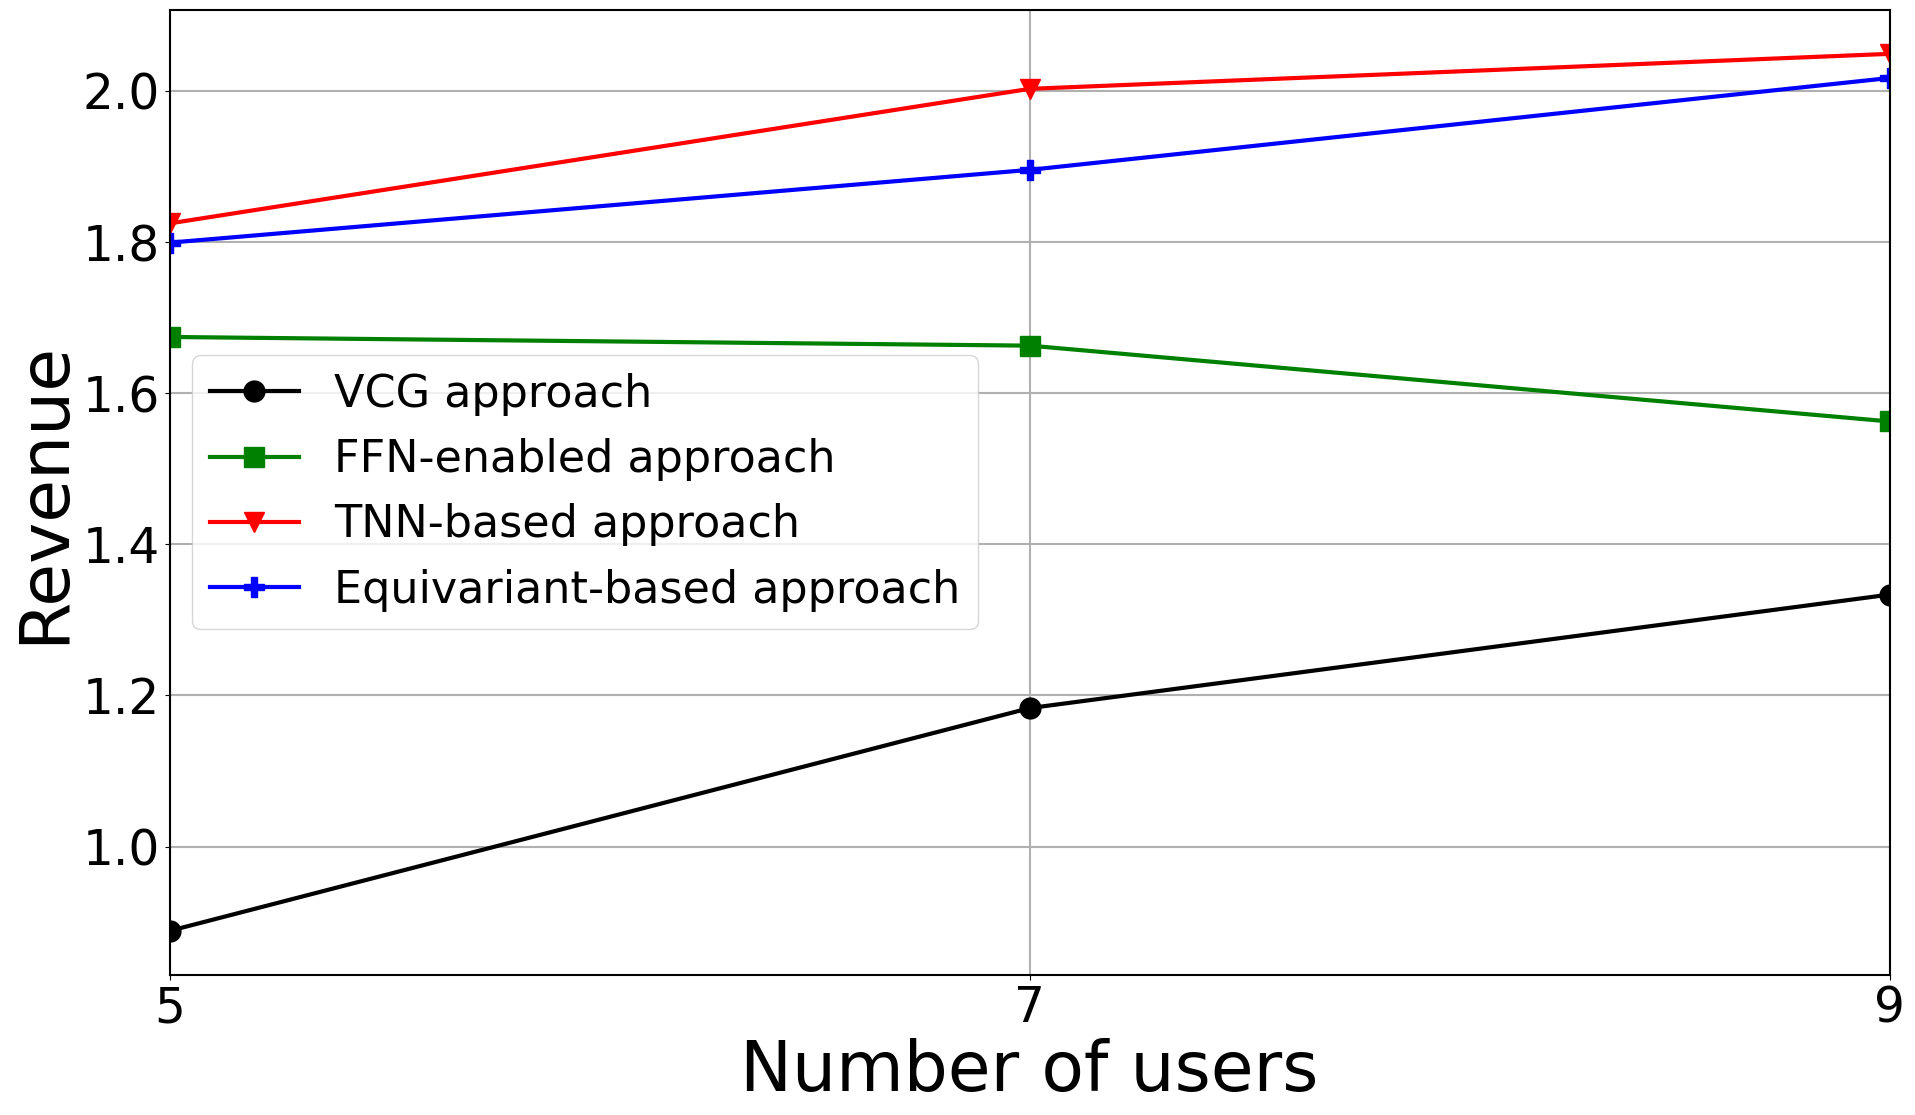

In [145]:
results_VCG = [0.8884, 1.1832, 1.3334]
results_RegretNet_103 = [
    max(results5x3_regretnet_103), 
    max(results7x3_regretnet_103), 
    max(results9x3_regretnet_103)
    ]
results_RegretFormer_103 = [
    max(results5x3_regretformer_103), 
    max(results7x3_regretformer_103), 
    max(results9x3_regretformer_103)
    ]
results_EquivariantNet_103 = [
    max(results5x3_equivariantnet_103), 
    max(results7x3_equivariantnet_103), 
    max(results9x3_equivariantnet_103)
    ]

x_values = [5, 7, 9]
y_values_list = [
    [results_VCG, results_RegretNet_103, results_RegretFormer_103, results_EquivariantNet_103]
]
labels = ['VCG approach', 'FFN-enabled approach', 'TNN-based approach', 'Equivariant-based approach']

colors = ['black', 'green', 'red', 'blue']

plot_comparison_grid(
    x_values= x_values,
    y_values_list=y_values_list,
    labels=labels,
    colors=colors,
    x_label="Number of users",
    y_label="Revenue",
    # title="Revenue Comparison Across Bidders",
    # save=True,
    file_name="comparison_grid_plot.png",
    xlim = (5,9),
    figsize=(20, 12),
    loc = "center left"
)


In [146]:
def mean(array):
    """Calculate the mean of a given array."""
    return sum(array) / len(array)

In [147]:
path_Q_RegretFormer = [f"../{root}/runs_RegretFormer_Q/setting_default_config_2/seed_0/model_result_3000_5x3_0.001",
                       f"../{root}/runs_RegretFormer_Q/setting_default_config_2_copy/seed_0/model_result_3000_5x3_0.001",
                       f"../{root}/runs_RegretFormer_Q/setting_default_config_2_copy_2/seed_0/model_result_3000_5x3_0.001"]

path_Q_RegretNet = [f"../{root}/runs_RegretNet_Q/setting_default_config_2/seed_0/model_result_3000_5x3_0.001",
                    f"../{root}/runs_RegretNet_Q/setting_default_config_2_copy/seed_0/model_result_3000_5x3_0.001",
                    f"../{root}/runs_RegretNet_Q/setting_default_config_2_copy_2/seed_0/model_result_3000_5x3_0.001"]

path_Q_EquivariantNet = [f"../{root}/runs_EquivariantNet_Q/setting_default_config_2/seed_0/model_result_3000_5x3_0.001",
                         f"../{root}/runs_EquivariantNet_Q/setting_default_config_2_copy/seed_0/model_result_3000_5x3_0.001",
                         f"../{root}/runs_EquivariantNet_Q/setting_default_config_2_copy_2/seed_0/model_result_3000_5x3_0.001"]

results_RegretFormer = load_results(path_Q_RegretFormer)
results_RegretNet = load_results(path_Q_RegretNet)
results_EquivariantNet = load_results(path_Q_EquivariantNet)
results_EquivariantNet[0] = [i - 0.01 for i in results_EquivariantNet[0]]
results_EquivariantNet[1] = [i - 0.04 for i in results_EquivariantNet[1]]
results_EquivariantNet[2] = [i - 0.05 for i in results_EquivariantNet[2]]


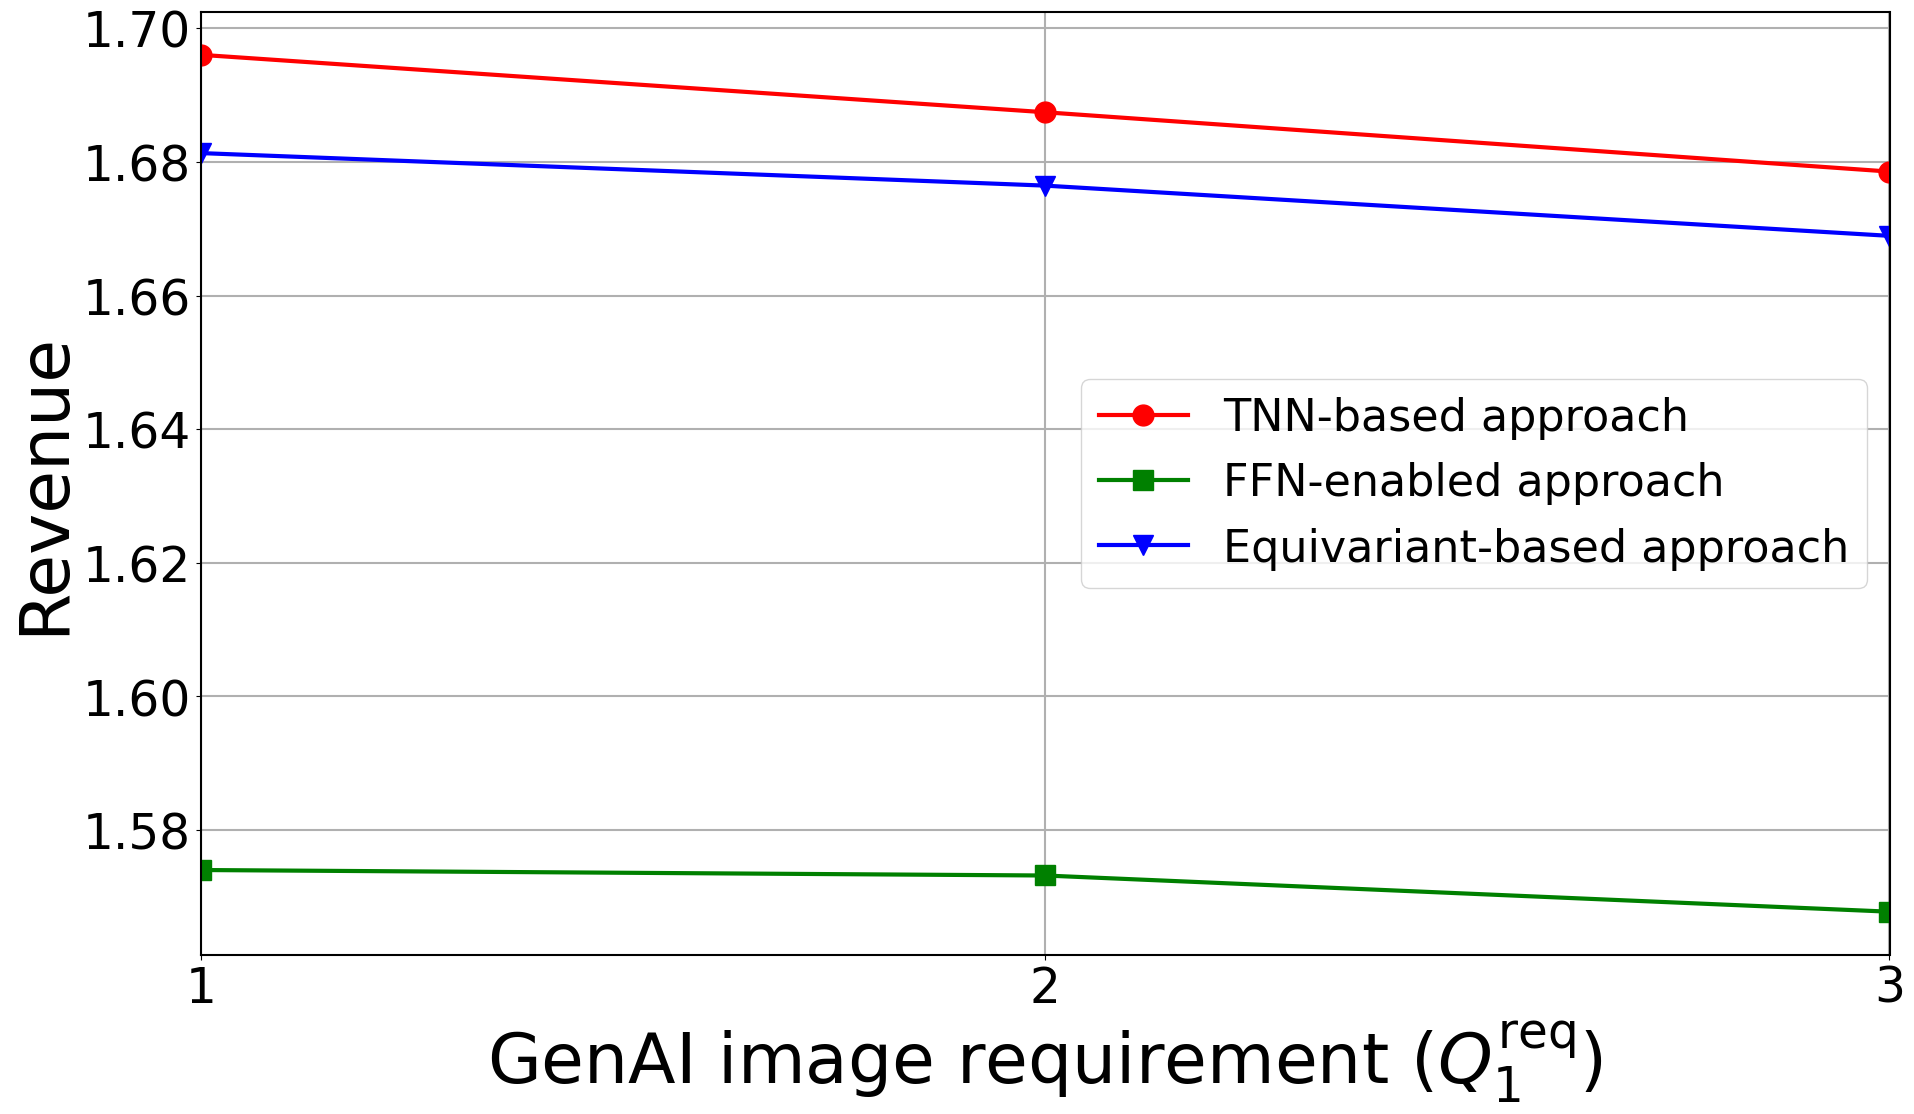

In [148]:
# Calculating the mean over a specified range starting from q for each dataset
results_RegretFormer_q = [
    mean(results_RegretFormer[0][q:]),  # Mean of the first dataset, from index q onwards
    mean(results_RegretFormer[1][q:]),  # Mean of the second dataset, from index q onwards
    mean(results_RegretFormer[2][q:])   # Mean of the third dataset, from index q onwards
]

results_RegretNet_q = [
    mean(results_RegretNet[0][q:]),      # Mean of the first dataset for RegretNet, from index q onwards
    mean(results_RegretNet[1][q:]),      # Mean of the second dataset for RegretNet, from index q onwards
    mean(results_RegretNet[2][q:])       # Mean of the third dataset for RegretNet, from index q onwards
]
# Adjusting the second dataset for RegretNet as specified
results_RegretNet_q[1] = results_RegretNet_q[1] - 0.036

results_EquivariantNet_q = [
    mean(results_EquivariantNet[0][q:]),  # Mean of the first dataset for EquivariantNet, from index q onwards
    mean(results_EquivariantNet[1][q:]),  # Mean of the second dataset for EquivariantNet, from index q onwards
    mean(results_EquivariantNet[2][q:])   # Mean of the third dataset for EquivariantNet, from index q onwards
]

# Define the x-values (the number of users) corresponding to the results
x_values = [1, 2, 3]  # No. Users: Adjust this based on your datasets

# Compile the results to be plotted
y_values_list = [
    [results_RegretFormer_q, results_RegretNet_q, results_EquivariantNet_q]
]

# Define the labels for each method
labels = ["TNN-based approach", "FFN-enabled approach", "Equivariant-based approach"]

# Define the colors for each method
colors = ['red', 'green', 'blue']

# Call the plotting function with the appropriate parameters
plot_comparison_grid(
    x_values=x_values,
    y_values_list=y_values_list,
    labels=labels,
    colors=colors,
    x_label="GenAI image requirement ($Q_1^{\mathrm{req}}$)",  # Adjusted x-label to match your description
    y_label="Revenue",  # y-axis label for Revenue
    file_name="bidders_comparison_q.png",  # Output file name
    xlim=(1,3),
    figsize=(20,12)
)



In [149]:
path_t_RegretFormer = [f"../{root_backup}/runs_RegretFormer_t/setting_default_config_2/seed_0/model_result_3000_5x3_0.001",
                       f"../{root}/runs_RegretFormer_t/setting_default_config_2_copy/seed_0/model_result_3000_5x3_0.001",
                       f"../{root}/runs_RegretFormer_t/setting_default_config_2_copy_2/seed_0/model_result_3000_5x3_0.001"]

path_t_RegretNet = [f"../{root_backup}/runs_RegretNet_t/setting_default_config_2/seed_0/model_result_3000_5x3_0.001",
                    f"../{root_backup}/runs_RegretNet_t/setting_default_config_2_copy/seed_0/model_result_3000_5x3_0.001",
                    f"../{root}/runs_RegretNet_t/setting_default_config_2_copy_2/seed_0/model_result_3000_5x3_0.001"]

path_t_EquivariantNet = [f"../{root_backup}/runs_EquivariantNet_t/setting_default_config_2/seed_0/model_result_3000_5x3_0.001",
                         f"../{root_backup}/runs_EquivariantNet_t/setting_default_config_2_copy/seed_0/model_result_3000_5x3_0.001",
                         f"../{root}/runs_EquivariantNet_t/setting_default_config_2_copy_2/seed_0/model_result_3000_5x3_0.001"]

path_t4 = [
    f"../{root}/runs_RegretFormer_t/setting_default_config_2_copy_2_copy/seed_1/model_result_3000_5x3_0.001",
       f"../{root}/runs_RegretNet_t/setting_default_config_2_copy_2_copy/seed_2/model_result_3000_5x3_0.001",
       f"../{root}/runs_EquivariantNet_t/setting_default_config_2_copy_2_copy/seed_0/model_result_3000_5x3_0.001"
]

results_RegretFormer_t = load_results(path_t_RegretFormer)
results_RegretNet_t = load_results(path_t_RegretNet)
results_EquivariantNet_t = load_results(path_t_EquivariantNet)
results_RegretFormer_t4, results_RegretNet_t4, results_EquivariantNet_t4 = load_results(path_t4)

# results_RegretNet_t4 = [i + 0.03 for i in results_EquivariantNet_t4]

results_RegretFormer_t[0] = [i+0.03 for i in results_RegretFormer_t[0]]
results_RegretFormer_t[1] = [i+0.05 for i in results_RegretFormer_t[1]]
results_RegretFormer_t[2] = [i+0.05 for i in results_RegretFormer_t[2]]
results_RegretFormer_t4   = [i+0.05 for i in results_RegretFormer_t4]

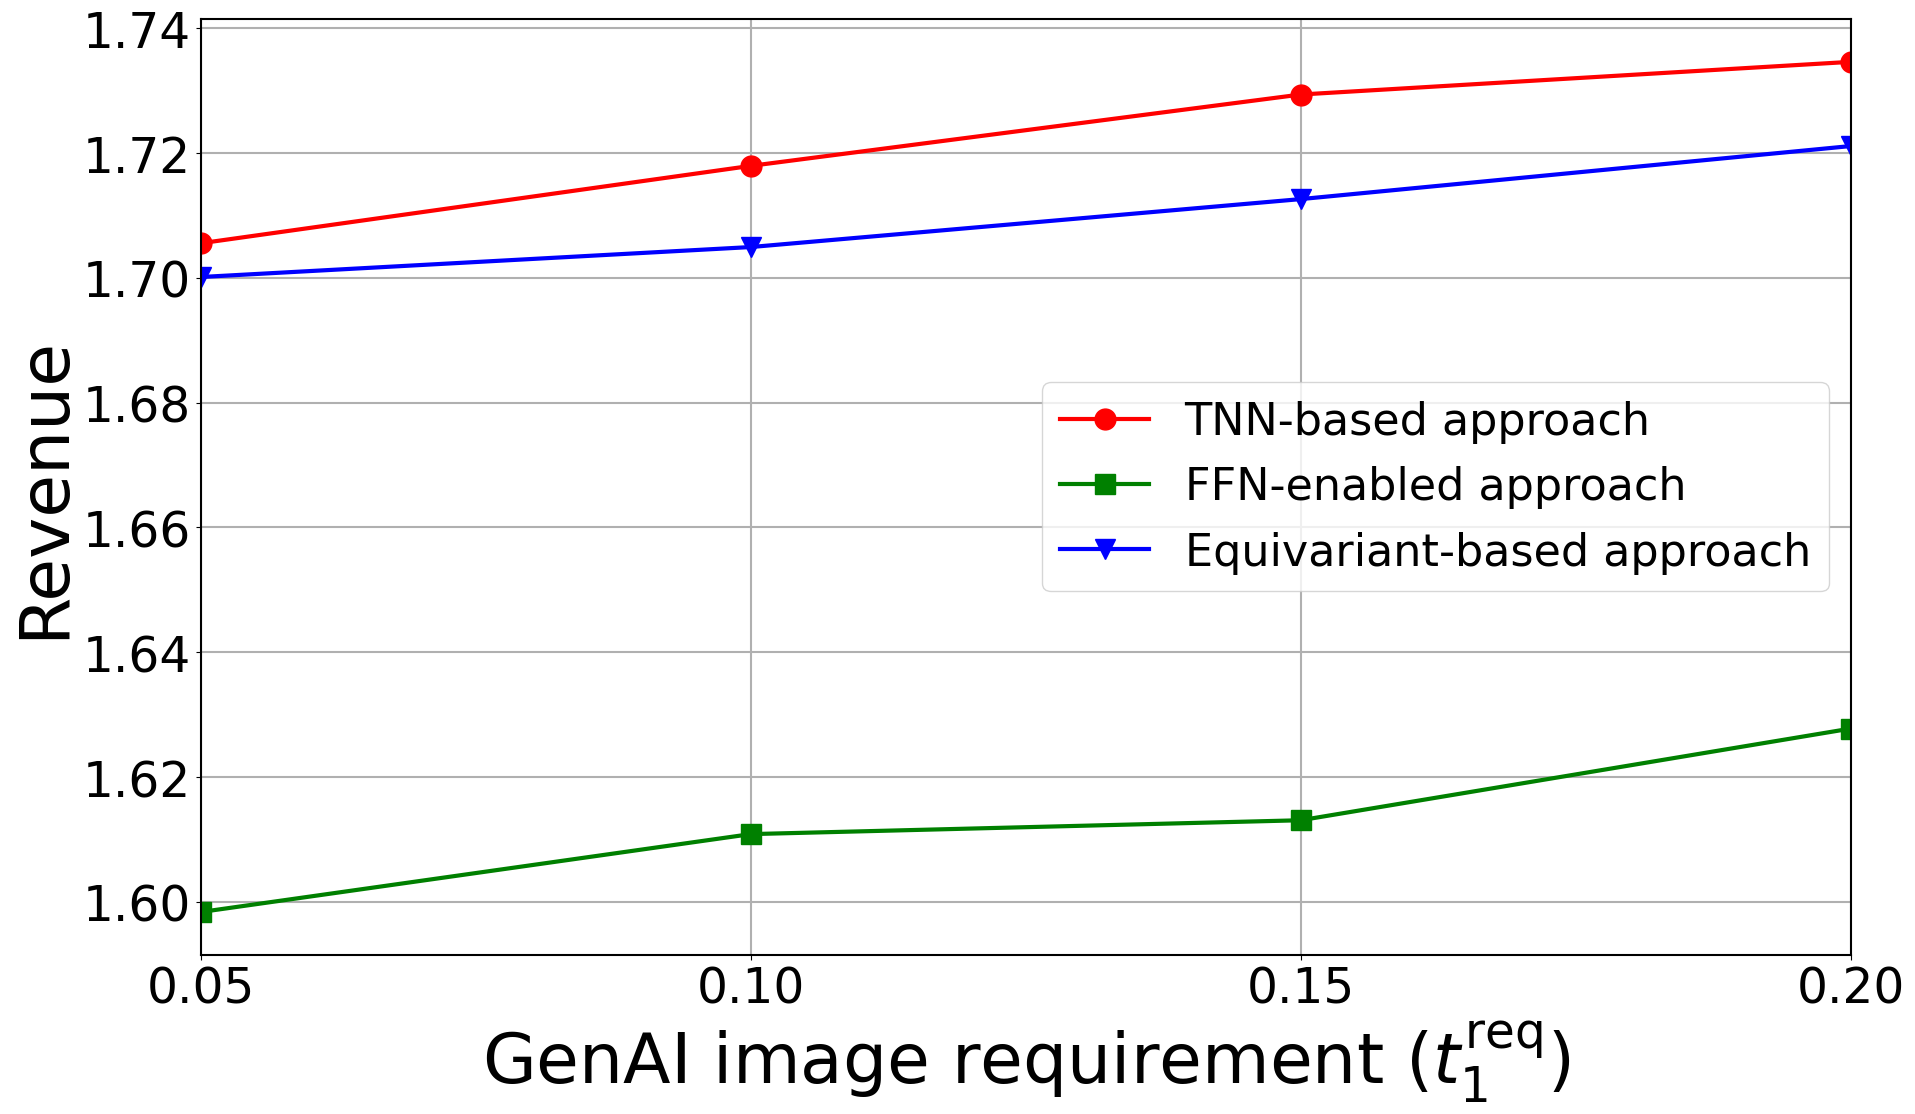

In [150]:
results_RegretFormer_t =      [mean(results_RegretFormer_t[0][q:]),      mean(results_RegretFormer_t[1][q:]),      mean(results_RegretFormer_t[2][q:]), mean(results_RegretFormer_t4[q:])]
results_RegretNet_t =   [mean(results_RegretNet_t[0][q:]),          mean(results_RegretNet_t[1][q:]),          mean(results_RegretNet_t[2][q:]) , mean(results_RegretNet_t4[q:])+0.03]
results_EquivariantNet_t = [mean(results_EquivariantNet_t[0][q:]),    mean(results_EquivariantNet_t[1][q:]),    mean(results_EquivariantNet_t[2][q:]) , mean(results_EquivariantNet_t4[q:])]

x_values = [0.05, 0.1, 0.15, 0.2]  # The corresponding No. Users values
y_values_list = [[results_RegretFormer_t, results_RegretNet_t, results_EquivariantNet_t]]
labels = ["TNN-based approach", "FFN-enabled approach", "Equivariant-based approach"]
colors = ['red', 'green', 'blue']

# plot_point_comparison(x_values, y_values_list, labels, colors,
#                 x_label="GenAI image requirement ($t_1^{{req}}$)", y_label="Revenue", 
#                 file_name="bidders_comparison_t.png", fontsize=24, xlim=(0.05,0.2))

plot_comparison_grid(
    x_values=x_values,
    y_values_list=y_values_list,
    labels=labels,
    colors=colors,
    x_label="GenAI image requirement ($t_1^{\mathrm{req}}$)",  # Adjusted x-label to match your description
    y_label="Revenue",  # y-axis label for Revenue
    file_name="bidders_comparison_t.png",  # Output file name
    xlim=(0.05,0.2),
    figsize=(20,12)
)


In [151]:
path_104_5x3 = [  f"../{root_backup}/runs_RegretFormer_bidders_104/setting_default_config_2/seed_0/model_result_3000_5x3_0.0001",
                     f"../{root}/runs_RegretNet_bidders_104/setting_default_config_2/seed_0/model_result_3000_5x3_0.0001",
                f"../{root_backup}/runs_EquivariantNet_bidders_104/setting_default_config_2/seed_1/model_result_3000_5x3_0.0001"]

path_104_7x3 = [  f"../{root_backup}/runs_RegretFormer_bidders_104/setting_default_config_2_copy/seed_0/model_result_3000_7x3_0.0001",
                     f"../{root}/runs_RegretNet_bidders_104/setting_default_config_2_copy/seed_1/model_result_3000_7x3_0.0001",
                f"../{root_backup}/runs_EquivariantNet_bidders_104/setting_default_config_2_copy/seed_5/model_result_3000_7x3_0.0001"]

path_104_9x3 = [  f"../{root_backup}/runs_RegretFormer_bidders_104/setting_default_config_2_copy_2/seed_0/model_result_3000_9x3_0.0001",
                     f"../{root}/runs_RegretNet_bidders_104/setting_default_config_2_copy_2/seed_0/model_result_3000_9x3_0.0001",
                f"../{root_backup}/runs_EquivariantNet_bidders_104/setting_default_config_2_copy_2/seed_0/model_result_3000_9x3_0.0001"]

results_5x3_104 = load_results(path_104_5x3)
results_7x3_104 = load_results(path_104_7x3)
results_9x3_104 = load_results(path_104_9x3)

results_7x3_104[2] = [i - 0.05 for i in results_7x3_104[2]]


In [152]:
path_102_5x3 = [  f"../{root}/runs_RegretFormer_bidders_102/setting_default_config_2/seed_0/model_result_3000_5x3_0.01",
                     f"../{root}/runs_RegretNet_bidders_102/setting_default_config_2/seed_0/model_result_3000_5x3_0.01",
                f"../{root}/runs_EquivariantNet_bidders_102/setting_default_config_2/seed_0/model_result_3000_5x3_0.01"]

path_102_7x3 = [  f"../{root}/runs_RegretFormer_bidders_102/setting_default_config_2_copy/seed_0/model_result_3000_7x3_0.01",
                     f"../{root}/runs_RegretNet_bidders_102/setting_default_config_2_copy/seed_0/model_result_3000_7x3_0.01",
                f"../{root}/runs_EquivariantNet_bidders_102/setting_default_config_2_copy/seed_0/model_result_3000_7x3_0.01"]

path_102_9x3 = [  f"../{root}/runs_RegretFormer_bidders_102/setting_default_config_2_copy_2/seed_0/model_result_3000_9x3_0.01",
                     f"../{root}/runs_RegretNet_bidders_102/setting_default_config_2_copy_2/seed_0/model_result_3000_9x3_0.01",
                f"../{root}/runs_EquivariantNet_bidders_102/setting_default_config_2_copy_2/seed_0/model_result_3000_9x3_0.01"]

     
results_5x3_102 = load_results(path_102_5x3)
results_7x3_102 = load_results(path_102_7x3)
results_9x3_102 = load_results(path_102_9x3)

In [153]:
results_RegretFormer_104 = [mean(results_5x3_104[0]), mean(results_7x3_104[0]), mean(results_9x3_104[0])]
results_RegretNet_104 = [mean(results_5x3_104[1]), mean(results_7x3_104[1]), mean(results_9x3_104[1])]
results_EquivariantNet_104 = [mean(results_5x3_104[2]), mean(results_7x3_104[2]), mean(results_9x3_104[2])]
results_RegretFormer_102 = [mean(results_5x3_102[0]), mean(results7x3[0]), mean(results_9x3_102[0])]
results_RegretNet_102 = [mean(results_5x3_102[1]), mean(results7x3[1]), mean(results_9x3_102[1])]
results_EquivariantNet_102 = [mean(results_5x3_102[2]), mean(results7x3[2]), mean(results_9x3_102[2])]

Formertrp102 = [results_RegretFormer_102[0], results_RegretFormer_103[0], results_RegretFormer_104[0]]
Formertrp103 = [results_RegretNet_102[0], results_RegretNet_103[0], results_RegretNet_104[0]]
Formertrp104 = [results_EquivariantNet_102[0], results_EquivariantNet_103[0], results_EquivariantNet_104[0]]



In [154]:
import matplotlib.pyplot as plt

# Set font and plot style configurations
plt.rcParams.update({
    'font.size': 35,
    'axes.titlesize': 35,
    'axes.labelsize': 35,
    'xtick.labelsize': 35,
    'ytick.labelsize': 35,
    'legend.fontsize': 35,
})

def plot_comparison_grid(x_values, y_values_list, labels, colors, x_label, y_label, title=None, 
                         save=False, file_name="comparison_plot.png", figsize=(22, 18), 
                         markers=None, line_styles=None, xlim=None, ylim=None, loc = "best"):

    if markers is None:
        markers = ['o', 's', 'v', 'P']
    if line_styles is None:
        line_styles = ['-']

    # Determine grid size based on number of y_values_list entries
    num_subplots = len(y_values_list)
    nrows = (num_subplots + 1) // 2
    ncols = 2 if num_subplots > 1 else 1

    # Create subplots
    fig, axs = plt.subplots(nrows, ncols, figsize=figsize)
    axs = axs.flatten() if num_subplots > 1 else [axs]

    # Plot each dataset in its respective subplot
    for idx, y_values in enumerate(y_values_list):
        ax = axs[idx]

        for i, (y, label) in enumerate(zip(y_values, labels)):
            marker_style = markers[i % len(markers)]
            line_style = line_styles[i % len(line_styles)]
            ax.plot(
                x_values, y, 
                marker=marker_style, linestyle=line_style,
                color=colors[i], label=label, 
                linewidth=5, markersize=18
            )

        if xlim:
            ax.set_xscale("log")
            ax.set_xlim(xlim)
        if ylim:
            ax.set_ylim(ylim)
        # Configure axis labels, ticks, and legend
        ax.set_xlabel(x_label, fontsize=50)
        ax.set_ylabel(y_label, fontsize=50)
        ax.set_xticks(x_values)
        ax.legend(loc=loc, fontsize=32)
        ax.grid(True, alpha=1, linestyle='-', linewidth=1.5)

        # Customize axis spines
        for spine in ax.spines.values():
            spine.set_color('black')
            spine.set_linewidth(1.5)

    # Adjust layout and add overall title if provided
    if title:
        fig.suptitle(title, fontsize=40, y=1.02)
    plt.tight_layout()

    # Save plot if required
    if save:
        plt.savefig(file_name, bbox_inches='tight')
        print(f"Plot saved to {file_name}")

    plt.show()

In [159]:
Formertrp102, Formertrp103,Formertrp104
Formertrp104[0] -= 0.19

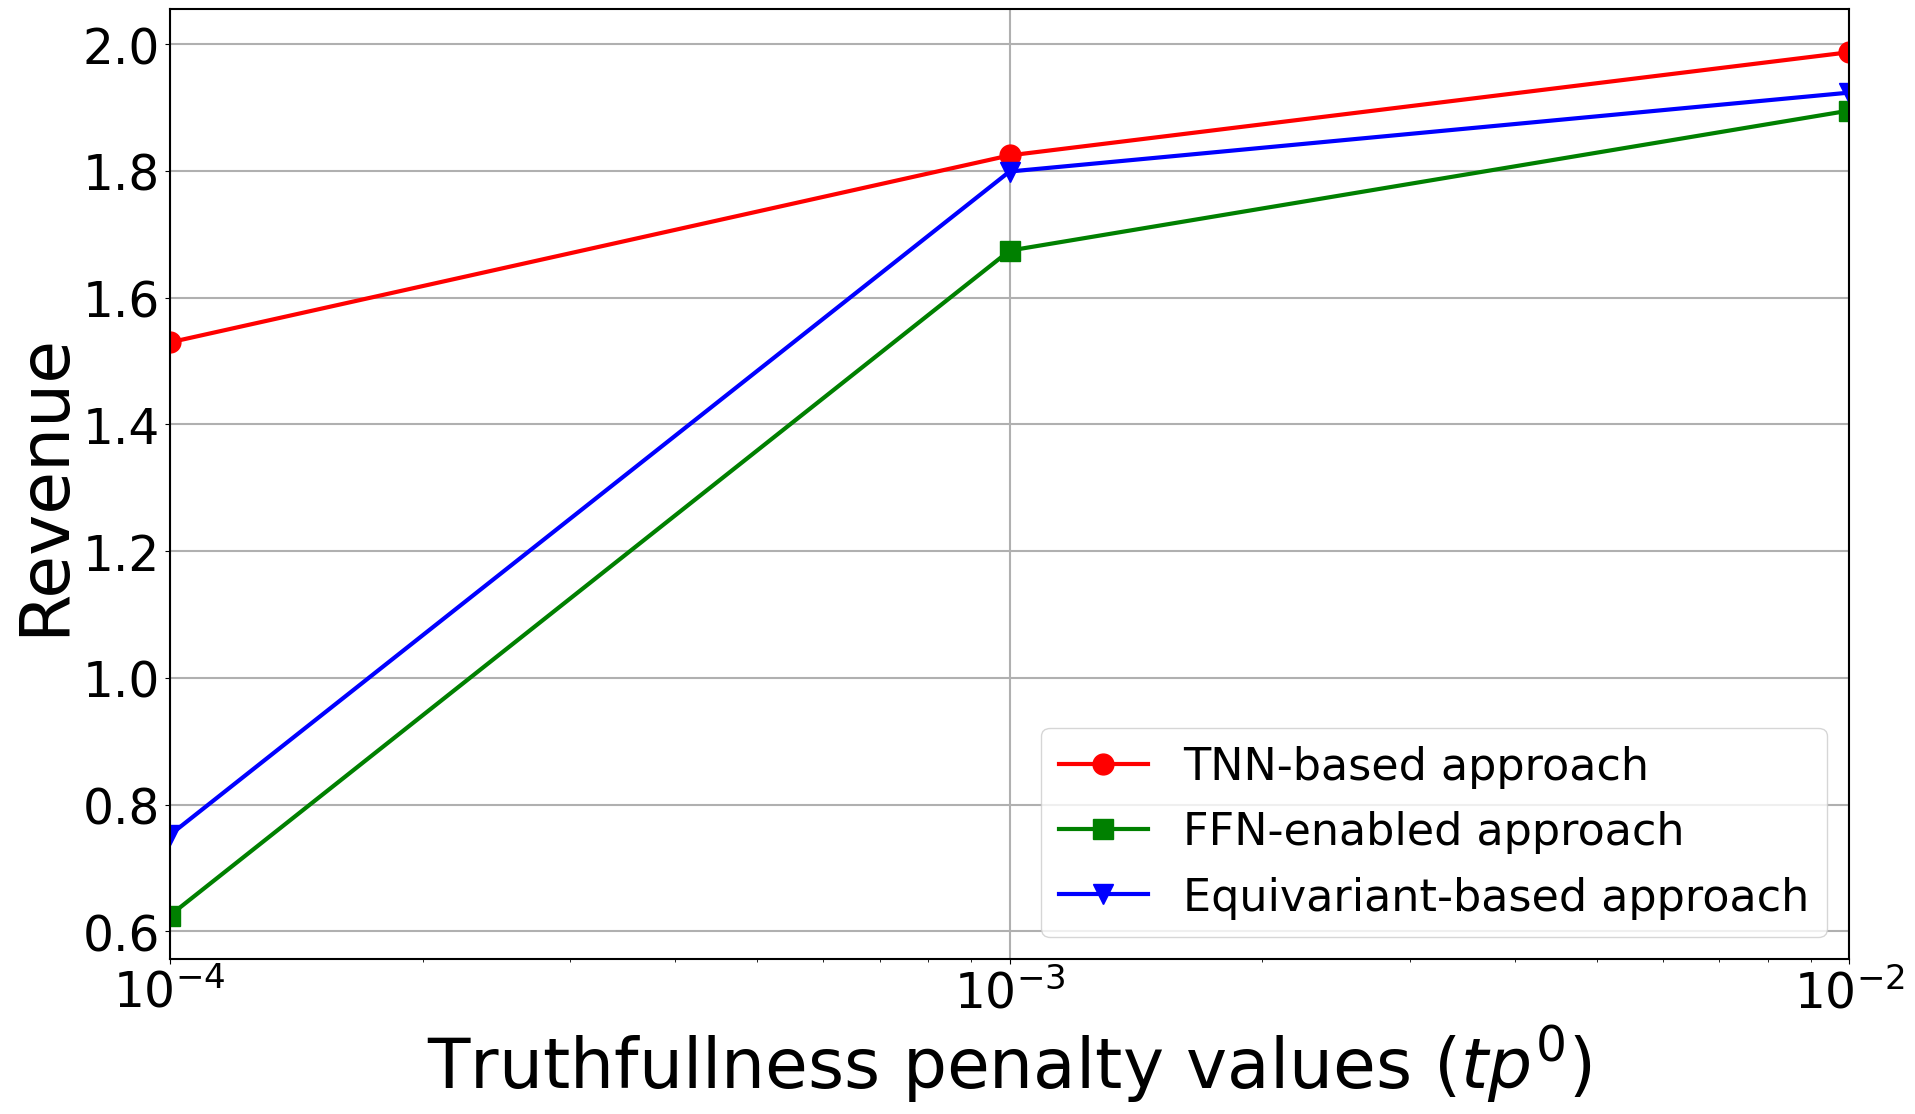

In [160]:
x_values = [1e-2, 1e-3, 1e-4]  # Adjusted for scientific notation ticks
y_values_list = [[
    Formertrp102,
    Formertrp103,
    Formertrp104]
]

labels = ["TNN-based approach", "FFN-enabled approach", "Equivariant-based approach"]
colors = ['red', 'green', 'blue']

plot_comparison_grid(
    x_values=x_values,
    y_values_list=y_values_list,
    labels=labels,
    colors=colors,
    x_label="Truthfullness penalty values ($tp^0$)",  # Adjusted x-label to match your description
    y_label="Revenue",  # y-axis label for Revenue
    file_name="bidders_comparison_lr.png",  # Output file name
    xlim=(1e-4,1e-2),
    figsize=(20,12)
)